# 02613 Mini-Project: Wall Heating!

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join
import os

### 1. Familiarize yourself with the data. Load and visualize the input data for a few floorplans using a separate Python script, Jupyter notebook or your preferred tool.

In [6]:
def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

In [7]:
def visualize_floorplans(load_dir, bids):
    """
    Loads and plots a list of floorplans.
    
    Args:
        load_dir (str): Path to the directory containing .npy files.
        bids (list): List of strings representing the floorplan IDs.
    """
    n = len(bids)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    
    # Handle single plan edge case
    if n == 1: axes = np.array([axes])

    for i, bid in enumerate(bids):
        try:
            u, mask = load_data(load_dir, bid)
            
            # Plot Domain
            im1 = axes[i, 0].imshow(u, cmap='viridis', origin='lower')
            axes[i, 0].set_title(f'Domain: {bid}')
            fig.colorbar(im1, ax=axes[i, 0])
            
            # Plot Interior Mask
            im2 = axes[i, 1].imshow(mask, cmap='binary', origin='lower')
            axes[i, 1].set_title(f'Interior Mask: {bid}')
            
        except FileNotFoundError as e:
            print(f"Error loading {bid}: {e}")
            
    plt.tight_layout()
    plt.savefig('../figures/task1_floorplans_visualization.png')
    plt.show()

Execution

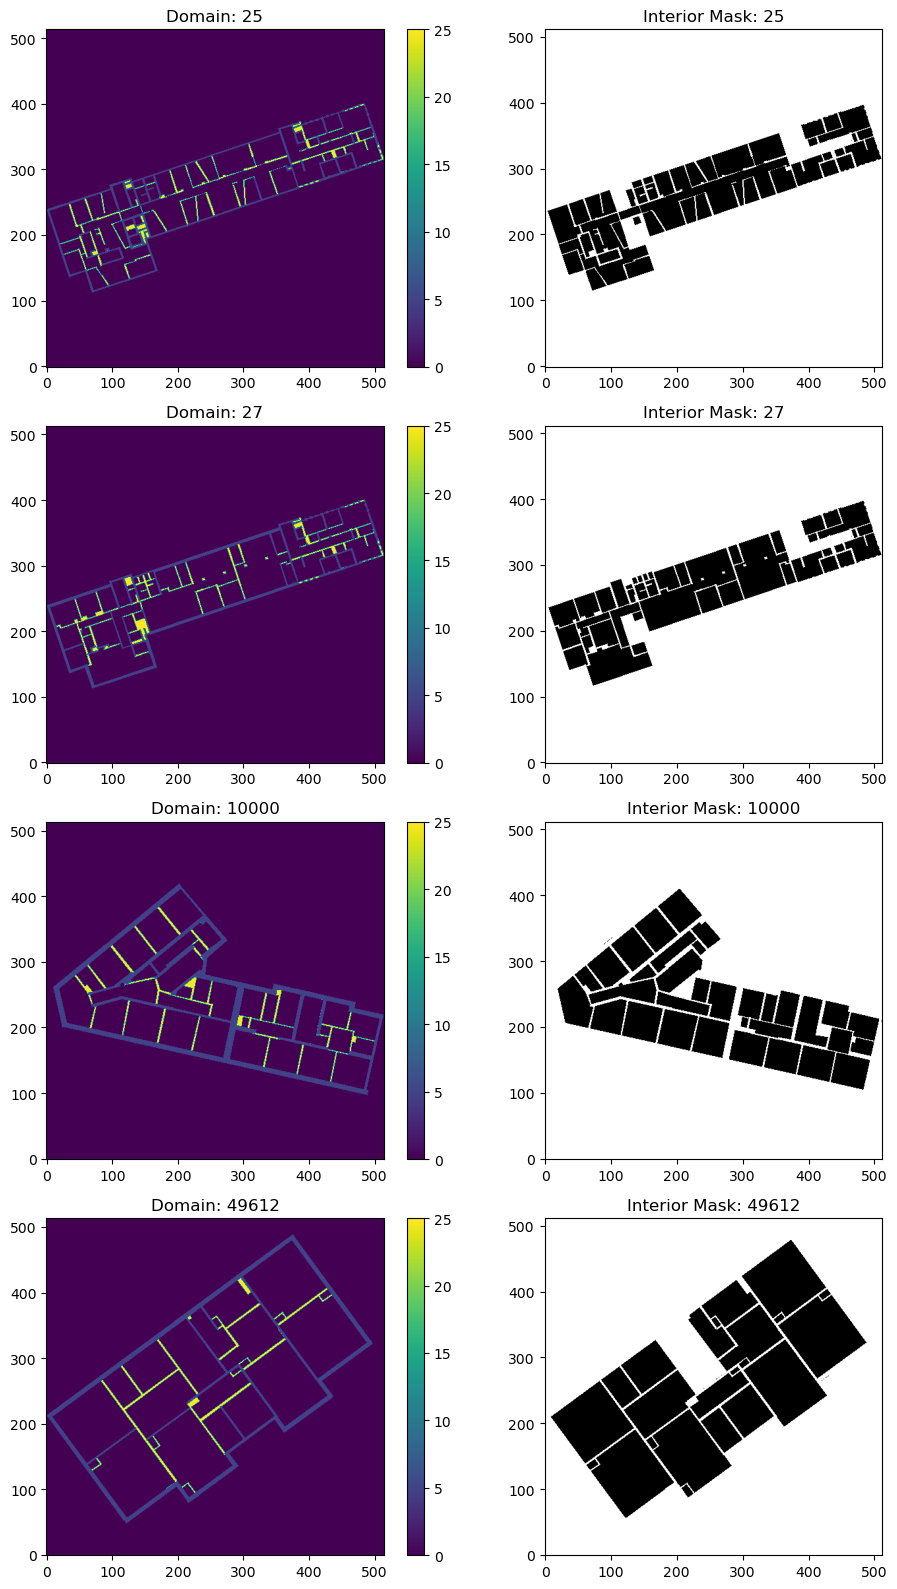

In [8]:
LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
building_ids = [25, 27, 10000, 49612]

visualize_floorplans(LOAD_DIR, building_ids)

In [9]:
files = [f for f in os.listdir(LOAD_DIR) if f.endswith("_domain.npy")]
num_samples = len(files)
print(f"Amount of files: {num_samples}")

Amount of files: 4571


### 2. Familiarize yourself with the provided script. Run and time the reference implementation for a small subset of floorplans (e.g., 10--20). How long do you estimate it would take to process all the floorplans? Perform the timing as a batch job so you get reliable results.

In [1]:
print(f'''The number of the data is {4571}
        real	4min24.29s
        user	262.80s
        sys	0.22s''')

times = (4*60+24.29)*(4571/20)
print(f"Total estimated time {int(times/60/60)} hr {int(times%3600/60)} min {int(times%60)} sec")

The number of the data is 4571
        real	4min24.29s
        user	262.80s
        sys	0.22s
Total estimated time 16 hr 46 min 43 sec


### 3. Visualize the simulation results for a few floorplans.

In [11]:
def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)
    for i in range(max_iter):
        # Compute average of left, right, up and down neighbors
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior
        
        if delta < atol:
            break
    return u

In [12]:
def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

Load data

In [13]:
LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
building_ids = [25, 27, 10000, 49612]
N = len(building_ids)
building_ids = building_ids[:N]

Load floor plans

In [14]:
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

Run jacobi iterations for each floor plan

In [15]:
MAX_ITER = 20_000
ABS_TOL = 1e-4

all_u = np.empty_like(all_u0)
for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u

Print summary statistics in CSV format

In [16]:
stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
print('building_id, ' + ', '.join(stat_keys))  # CSV header
for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
    stats = summary_stats(u, interior_mask)
    print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))

building_id, mean_temp, std_temp, pct_above_18, pct_below_15
25, 17.0022261743727, 6.7803048465418385, 51.77257696547127, 38.64807362026095
27, 14.991747695770927, 6.784942885131829, 38.51429156324369, 51.127203869085704
10000, 14.01233878811275, 6.367431059312565, 30.941014791508444, 55.542295034537624
49612, 13.460591469095686, 6.734679615855858, 32.03209152026149, 58.8901682576236


/tmp/ipykernel_1580372/411550268.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.94, 1])


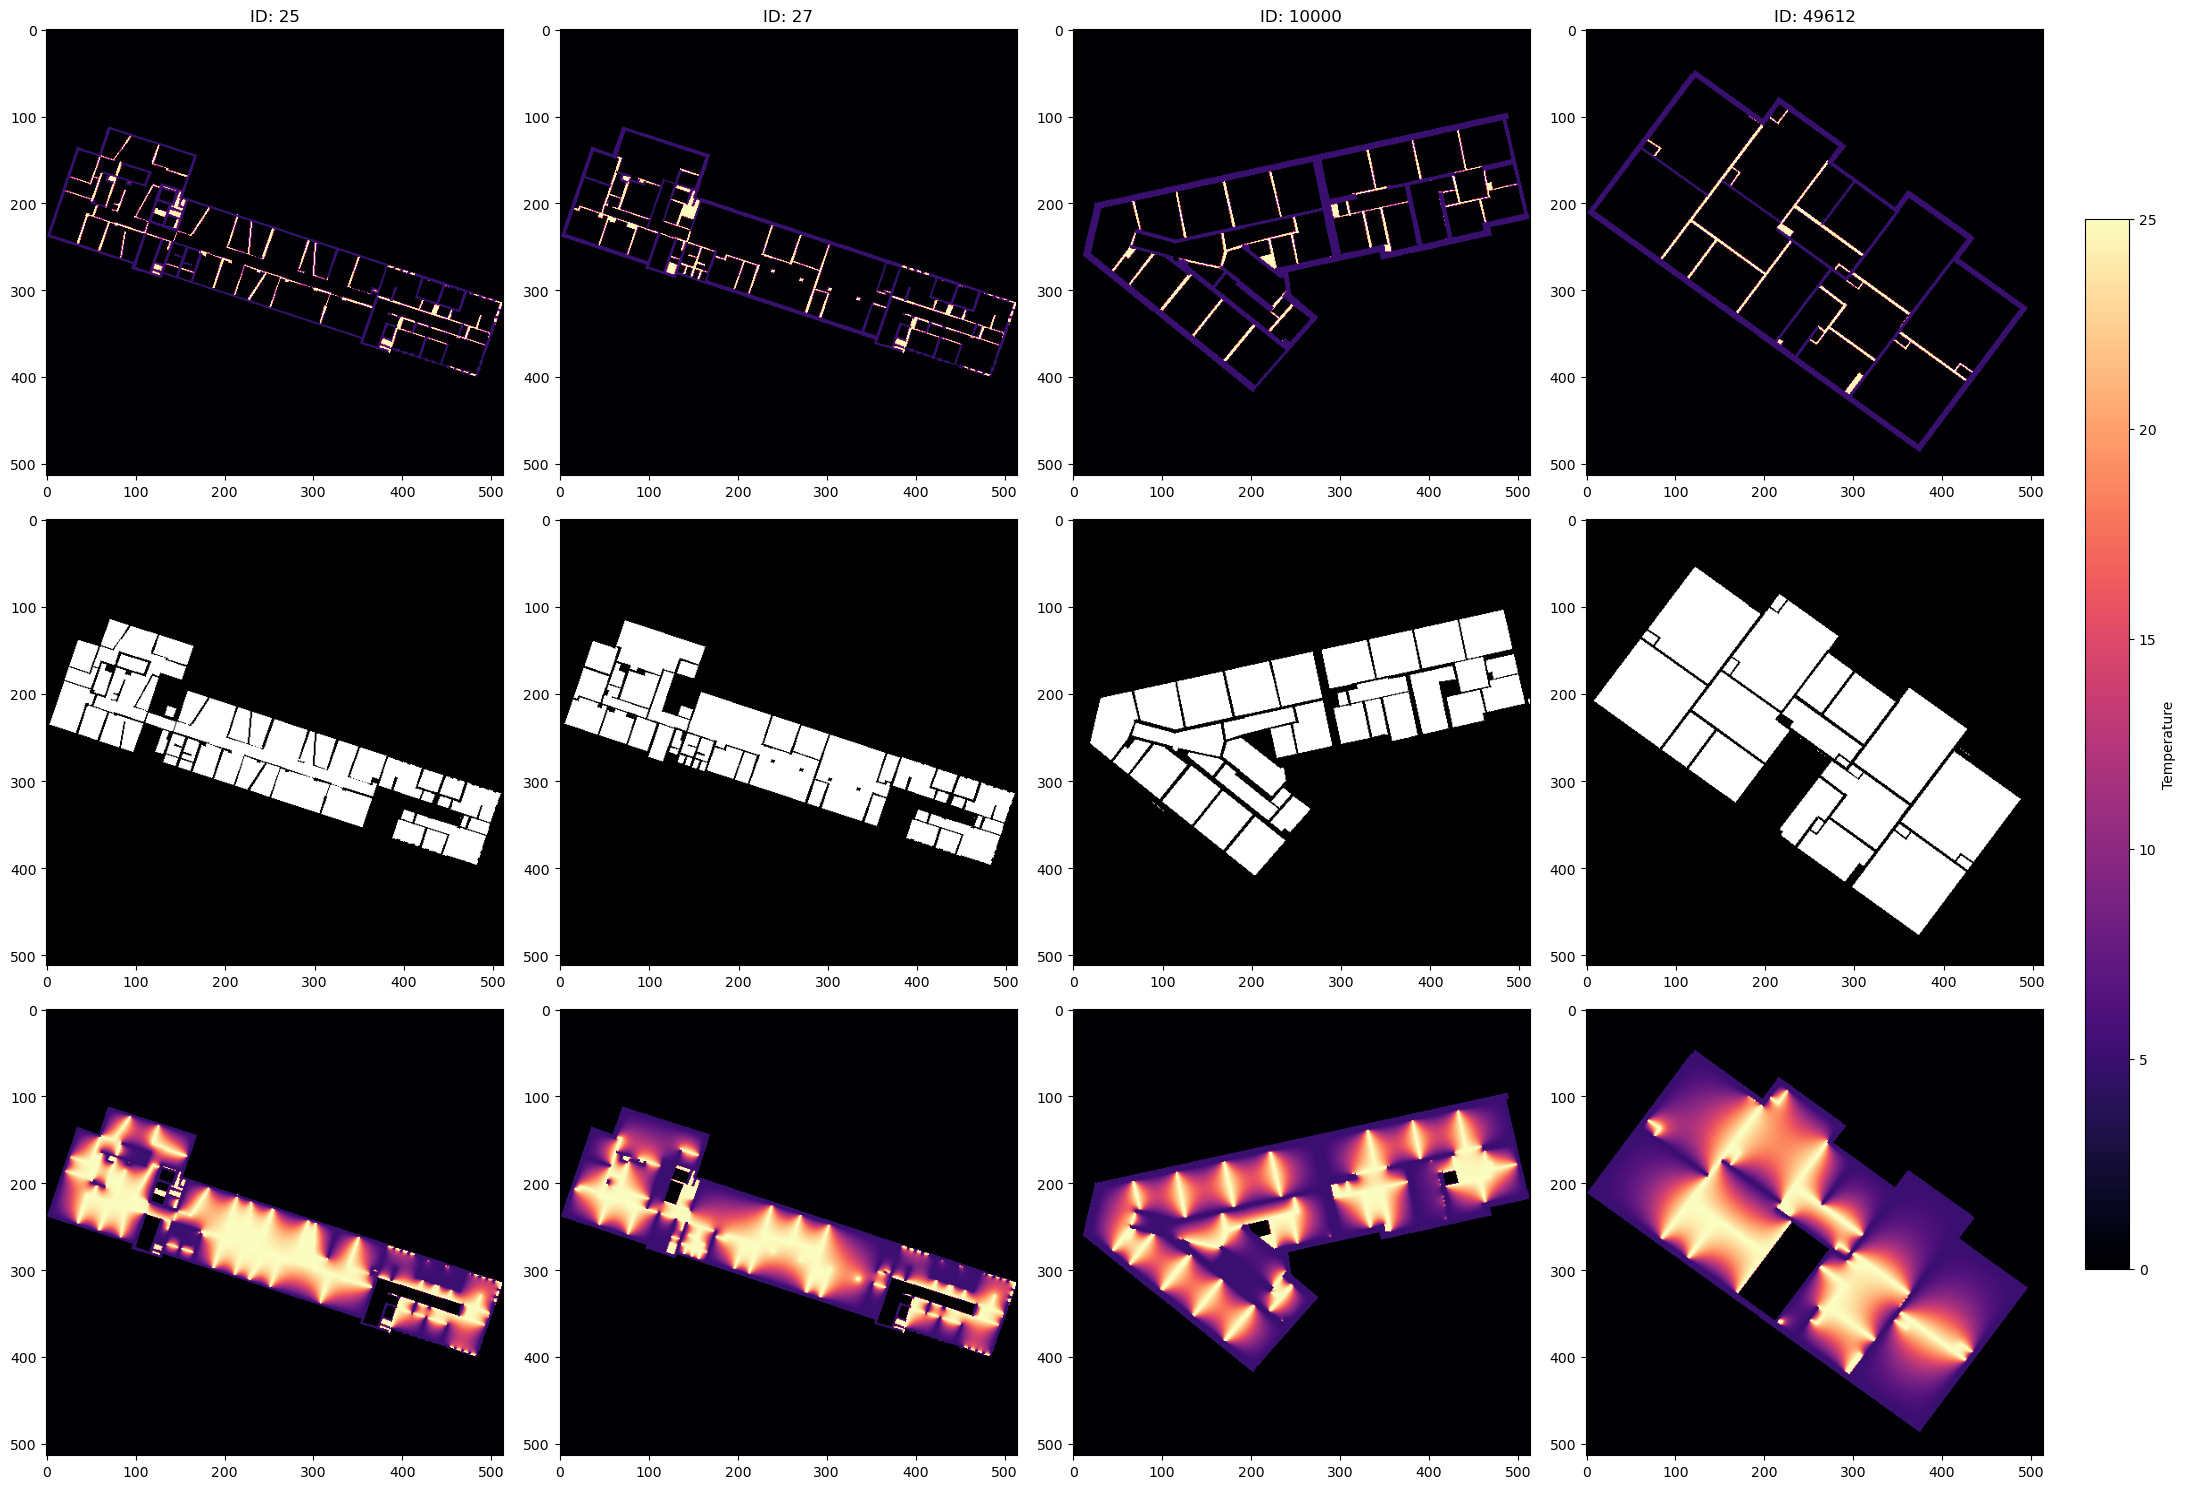

In [17]:
Vis_N = 4

fig, axes = plt.subplots(3, Vis_N, figsize=(N*5+2, 15))

for i, (id, u0, interior_mask, u) in enumerate(zip(building_ids[:Vis_N], all_u0[:Vis_N], all_interior_mask[:Vis_N], all_u[:Vis_N])):
    title = f"ID: {id}"
    im = axes[0,i].imshow(u0, cmap='magma', aspect='auto')
    axes[0,i].set_title(title)
    axes[1,i].imshow(interior_mask, cmap='binary_r', aspect='auto')  
    im = axes[2,i].imshow(u, cmap='magma', aspect='auto')
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])  
fig.colorbar(im, cax=cbar_ax, label="Temperature")

plt.tight_layout(rect=[0, 0, 0.94, 1])  

plt.savefig("../figures/task3_Visualize.png")

### 4. Profile the reference jacobi function using kernprof. Explain the different parts of the function and how much time each part takes.

In [3]:
'''
Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    19                                           @profile
    20                                           def jacobi(u, interior_mask, max_iter, atol=1e-6):
    21         1       1125.6   1125.6      0.0      u = np.copy(u)
    22      3602       2407.1      0.7      0.0      for i in range(max_iter):
    23                                                   # Compute average of left, right, up and down neighbors
    24      3602    4725299.6   1311.9     65.7          u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
    25      3602     637513.5    177.0      8.9          u_new_interior = u_new[interior_mask]
    26                                                   
    27      3602    1152977.3    320.1     16.0          delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
    28      3602     673384.1    186.9      9.4          u[1:-1, 1:-1][interior_mask] = u_new_interior
    29                                                   
    30      3602       4872.1      1.4      0.1          if delta < atol:
    31         1          1.1      1.1      0.0              break
    32         1          1.9      1.9      0.0      return u
'''

'\nLine #      Hits         Time  Per Hit   % Time  Line Contents\n==============================================================\n    19                                           @profile\n    20                                           def jacobi(u, interior_mask, max_iter, atol=1e-6):\n    21         1       1125.6   1125.6      0.0      u = np.copy(u)\n    22      3602       2407.1      0.7      0.0      for i in range(max_iter):\n    23                                                   # Compute average of left, right, up and down neighbors\n    24      3602    4725299.6   1311.9     65.7          u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])\n    25      3602     637513.5    177.0      8.9          u_new_interior = u_new[interior_mask]\n    26                                                   \n    27      3602    1152977.3    320.1     16.0          delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()\n    28      3602     673384.1    1